## Importowanie bibliotek, konfiguracja ścieżek


In [1]:
import os
import sys
import pandas as pd

from train.reporting.fact_classifier_reporter import FactClassifierReporter

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
app_root = os.path.abspath(os.path.join(project_root, '../../app', '..'))

if project_root not in sys.path:
    sys.path.append(project_root)
    sys.path.append(app_root)

## Odczytywanie datasetu csv i zapis do DataFrame

In [2]:
df = pd.read_csv('./csv_fact_generative/fact_generative_questions.csv')
df['fact'].value_counts(ascending=False)

fact
1    11720
0     2207
Name: count, dtype: int64

## Wyodrębnienie pytań z całego DataFrame'u - po 2000 pytań z obydwu kategorii

In [3]:
n_samples = 2000

fact_df = df[df["fact"] == 1].sample(n=n_samples, random_state=42)
generative_df = df[df["fact"] == 0].sample(n=n_samples, random_state=42)

full_df = pd.concat([fact_df, generative_df], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

full_df["fact"].value_counts()

fact
1    2000
0    2000
Name: count, dtype: int64

In [4]:
from train.reporting.text_svm_wrapper import TextSVMWrapper

report_df = full_df

reporter = FactClassifierReporter(TextSVMWrapper(), report_df['question'],
                         report_df['fact'])

## Rozpoczęcie treningu wraz z kroswalidacją. Generowanie raportu i najważniejszych wykresów. Zapis wyników do folderu 'reports'

In [5]:
reporter.generate_report()

[INFO] Raport zostanie zapisany w: reports\2026-06-11_21-24-13_TextSVMWrapper
Raport wygenerowany: 2026-06-11 21:24:13.532962
Model Wrapper: TextSVMWrapper
------------------------------
--- Rozpoczynanie treningu ---
Trening zakończony. Czas trwania: 2.14 s
[INFO] Brak historii funkcji straty (Loss History). Pomijam wykres.
Zapisano macierz pomyłek: reports\2026-06-11_21-24-13_TextSVMWrapper\confusion_matrix.png

--- Repeated Stratified CV: 5 foldów x 3 powtórzeń ---

--- Wyniki walidacji krzyżowej ---
test_accuracy: 0.9549 (+/- 0.0069)
train_accuracy: 0.9921 (+/- 0.0008)
test_balanced_accuracy: 0.9549 (+/- 0.0069)
train_balanced_accuracy: 0.9921 (+/- 0.0008)
test_f1_macro: 0.9549 (+/- 0.0069)
train_f1_macro: 0.9921 (+/- 0.0008)
test_precision_macro: 0.9550 (+/- 0.0069)
train_precision_macro: 0.9922 (+/- 0.0007)
test_recall_macro: 0.9549 (+/- 0.0069)
train_recall_macro: 0.9921 (+/- 0.0008)
test_roc_auc: 0.9883 (+/- 0.0022)
train_roc_auc: 0.9996 (+/- 0.0001)
Zapisano wyniki CV: reports

Generowanie mapy t-SNE (to może chwilę potrwać)...


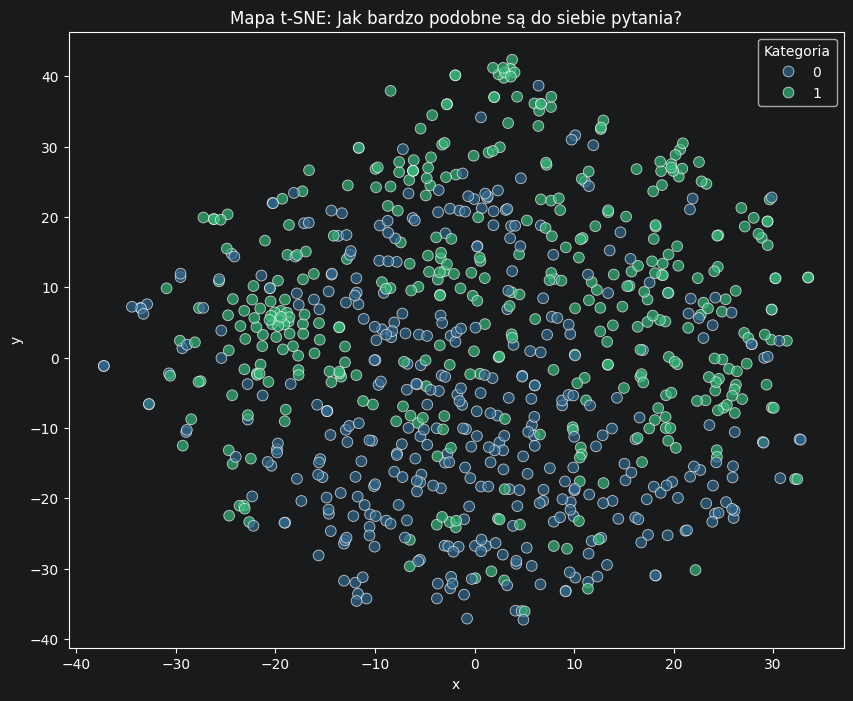

In [6]:
reporter.plot_tsne()

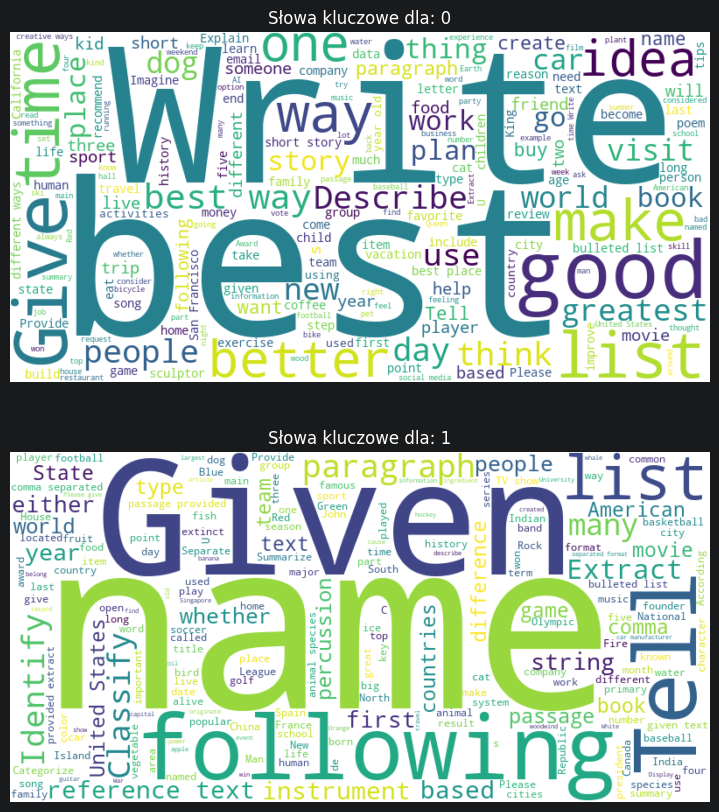

In [7]:
reporter.plot_wordclouds()

In [8]:
reporter.plot_confusion_matrix()

Zapisano macierz pomyłek: reports\2026-06-11_21-24-13_TextSVMWrapper\confusion_matrix.png


Zapisano rozkład pewności modelu: reports\2026-06-11_21-24-13_TextSVMWrapper\confidence_distr_plot.png


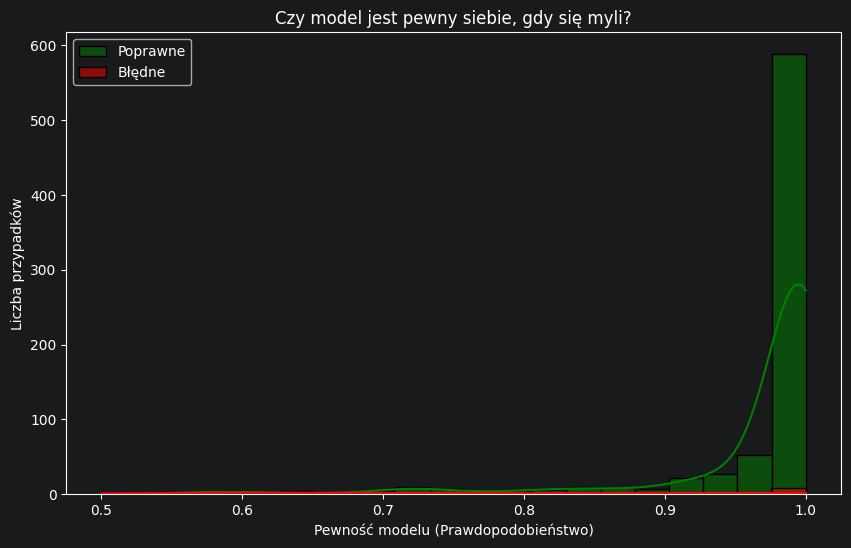

In [9]:
reporter.plot_confidence_distribution()